# PFE 2026 — Suivi des Catastrophes Naturelles au Maroc

- **Target** : `severity_label` (low / medium / high)
- **Dataset** : `data_seismes.csv`
- **Modèles** : Régression Logistique, Arbre de Décision, Random Forest

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

## 1. Chargement des données

Shape brute : (2841, 22)
Colonnes disponibles : ['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status', 'locationSource', 'magSource']
✅ severity_label créée depuis mag (mag sera exclue des features)

Distribution severity_label :
severity_label
low       2370
medium     432
high        39
Name: count, dtype: int64


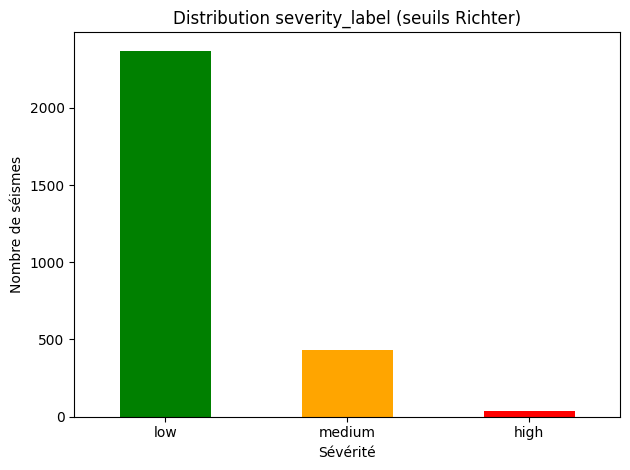

In [14]:
df = pd.read_csv('../data/data_seismes.csv')
print('Shape brute :', df.shape)
print('Colonnes disponibles :', list(df.columns))

# ----- Créer severity_label à partir de mag UNIQUEMENT -----
# ⚠️  mag sera EXCLUE des features pour éviter le data leakage
# Seuils basés sur l'échelle de Richter et les standards sismologiques :
# low    : mag < 4.0  (séisme mineur, peu ou pas de dégâts)
# medium : 4.0 ≤ mag < 5 (séisme modéré, dégâts légers possibles)
# high   : mag ≥ 5 (séisme fort, dégâts significatifs)
def assign_severity(mag):
    if mag >= 5:
        return 'high'
    elif mag >= 4.0:
        return 'medium'
    else:
        return 'low'

df['severity_label'] = df['mag'].apply(assign_severity)
print('✅ severity_label créée depuis mag (mag sera exclue des features)')

print('\nDistribution severity_label :')
print(df['severity_label'].value_counts())

# ----- Visualisation -----
colors = {'low': 'green', 'medium': 'orange', 'high': 'red'}
counts = df['severity_label'].value_counts()
counts.plot(kind='bar',
            color=[colors.get(c, 'gray') for c in counts.index])
plt.title('Distribution severity_label (seuils Richter)')
plt.xlabel('Sévérité')
plt.ylabel('Nombre de séismes')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Diagnostic des données (NaN par colonne)

In [15]:
print('=== Taille totale du dataset ===')
print(f'Lignes : {df.shape[0]}, Colonnes : {df.shape[1]}')
print()
print('=== NaN par colonne (features candidates) ===')
cols_check = ['latitude','longitude','depth','mag','nst','gap','dmin','rms',
              'magType','net','type','locationSource','magSource',
              'horizontalError','depthError','magError','magNst','status']
cols_check = [c for c in cols_check if c in df.columns]
nan_report = pd.DataFrame({
    'NaN count' : df[cols_check].isnull().sum(),
    'NaN %'     : (df[cols_check].isnull().sum() / len(df) * 100).round(1)
})
print(nan_report.to_string())
print()
print('=== Distribution severity_label ===')
print(df['severity_label'].value_counts())
print()
print('=== Lignes restantes si on dropna sur chaque feature seule ===')
for c in ['nst','gap','dmin','rms','latitude','longitude','depth']:
    if c in df.columns:
        n = df[[c,'severity_label']].dropna().shape[0]
        print(f'  {c:<15} → {n} lignes')

=== Taille totale du dataset ===
Lignes : 2841, Colonnes : 23

=== NaN par colonne (features candidates) ===
                 NaN count  NaN %
latitude                 0    0.0
longitude                0    0.0
depth                    0    0.0
mag                      0    0.0
nst                    810   28.5
gap                    922   32.5
dmin                  2663   93.7
rms                   1995   70.2
magType                  0    0.0
net                      0    0.0
type                     0    0.0
locationSource           0    0.0
magSource                0    0.0
horizontalError       2679   94.3
depthError            2548   89.7
magError              2661   93.7
magNst                2516   88.6
status                   0    0.0

=== Distribution severity_label ===
severity_label
low       2370
medium     432
high        39
Name: count, dtype: int64

=== Lignes restantes si on dropna sur chaque feature seule ===
  nst             → 2031 lignes
  gap             → 1919 l

## 3. Preprocessing

In [16]:
# ----- Sélection des features numériques pertinentes -----
# ❌ 'mag'  exclue : utilisée pour construire severity_label → data leakage
# ❌ 'dmin' exclue : 93.7% NaN
# ❌ 'rms'  exclue : 70.2% NaN
# ⚠️  'nst' et 'gap' : ~30% NaN → imputation par médiane
features_candidates = ['latitude', 'longitude', 'depth', 'nst', 'gap']

# Garder seulement celles disponibles dans le CSV
features = [f for f in features_candidates if f in df.columns]

# ----- Imputation par médiane (évite de perdre des lignes) -----
for col in features:
    nb_nan = df[col].isnull().sum()
    if nb_nan > 0:
        df[col] = df[col].fillna(df[col].median())
        print(f'  {col} : {nb_nan} NaN remplacés par la médiane ({df[col].median():.3f})')

# ----- Encodage des colonnes catégorielles -----
cat_cols = ['magType', 'net', 'locationSource', 'magSource']
le_dict = {}
for col in cat_cols:
    if col in df.columns:
        lec = LabelEncoder()
        df[col + '_enc'] = lec.fit_transform(df[col].astype(str).fillna('unknown'))
        le_dict[col] = lec
        features.append(col + '_enc')
        print(f'✅ {col} encodée → {col}_enc')

# One-Hot pour 'type'
if 'type' in df.columns:
    dummies = pd.get_dummies(df['type'].astype(str).fillna('unknown'), prefix='type')
    df = pd.concat([df, dummies], axis=1)
    type_cols = list(dummies.columns)
    features += type_cols
    print(f'✅ type OHE → {type_cols}')

print('\nFeatures finales :', features)

# ----- Pas de dropna : toutes les lignes sont conservées -----
df_clean = df[features + ['severity_label']].copy()
print(f'\nLignes conservées : {df_clean.shape[0]} (sur {df.shape[0]} total)')

# ----- Encodage de la target -----
le = LabelEncoder()
df_clean['severity_encoded'] = le.fit_transform(df_clean['severity_label'])
print('\nClasses encodées :', dict(zip(le.classes_, le.transform(le.classes_))))
print('\nDistribution des classes :')
print(df_clean['severity_label'].value_counts())

X = df_clean[features].values
y = df_clean['severity_encoded'].values

# ⚠️  IMPORTANT : le scaler est fitté APRÈS le split (section 4)
#     pour éviter le data leakage du preprocessing
print('\n✅ Preprocessing terminé — normalisation après split (section 4)')

  nst : 810 NaN remplacés par la médiane (11.000)
  gap : 922 NaN remplacés par la médiane (270.000)
✅ magType encodée → magType_enc
✅ net encodée → net_enc
✅ locationSource encodée → locationSource_enc
✅ magSource encodée → magSource_enc
✅ type OHE → ['type_earthquake', 'type_mining explosion']

Features finales : ['latitude', 'longitude', 'depth', 'nst', 'gap', 'magType_enc', 'net_enc', 'locationSource_enc', 'magSource_enc', 'type_earthquake', 'type_mining explosion']

Lignes conservées : 2841 (sur 2841 total)

Classes encodées : {'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

Distribution des classes :
severity_label
low       2370
medium     432
high        39
Name: count, dtype: int64

✅ Preprocessing terminé — normalisation après split (section 4)


## 3. Split Train/Test + SMOTE (sur train uniquement)

In [17]:
# ----- Split 65/35 -----
min_class_count = pd.Series(y).value_counts().min()
use_stratify = y if min_class_count >= 2 else None
if use_stratify is None:
    print('⚠️  Stratification désactivée : une classe a moins de 2 exemples')
else:
    print('✅ Stratification activée')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=use_stratify
)
print(f'Train : {X_train.shape}, Test : {X_test.shape}')
print('Distribution train avant SMOTE :', pd.Series(y_train).value_counts().to_dict())

# ----- Normalisation APRÈS split (fit sur train uniquement) -----
# ✅ Evite le data leakage : le scaler ne voit pas les données de test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit + transform sur train
X_test  = scaler.transform(X_test)        # transform uniquement sur test
print('✅ Normalisation appliquée (fit sur train uniquement)')

# ----- SMOTE ciblé : rééquilibrer 'high' vers ~50% de 'medium' -----
# On ne sur-sample pas jusqu'à égalité totale pour rester réaliste
counts = pd.Series(y_train).value_counts().to_dict()
high_idx  = list(le.classes_).index('high')    if 'high'   in le.classes_ else None
med_idx   = list(le.classes_).index('medium')  if 'medium' in le.classes_ else None
low_idx   = list(le.classes_).index('low')     if 'low'    in le.classes_ else None

# Cible : high → 50% du nb de medium, medium et low restent inchangés
sampling_strategy = {}
if high_idx is not None and med_idx is not None:
    target_high = max(counts.get(high_idx, 0), int(counts.get(med_idx, 0) * 0.5))
    sampling_strategy[high_idx] = target_high

smote = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print('Distribution train après SMOTE :', pd.Series(y_train_res).value_counts().to_dict())
print(f'Train final : {X_train_res.shape}')

✅ Stratification activée
Train : (1988, 11), Test : (853, 11)
Distribution train avant SMOTE : {1: 1659, 2: 302, 0: 27}
✅ Normalisation appliquée (fit sur train uniquement)
Distribution train après SMOTE : {1: 1659, 2: 302, 0: 151}
Train final : (2112, 11)


## 4. Entraînement des 3 modèles

In [18]:
# ----- Définition des modèles -----
# class_weight='balanced' : pénalise davantage les erreurs sur les classes rares (high)
models = {
    'Régression Logistique': LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced'
    ),
    'Arbre de Décision': DecisionTreeClassifier(
        max_depth=8, random_state=42,
        class_weight='balanced'
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=None,        # arbres profonds pour capturer 'high'
        min_samples_leaf=1,    # permettre feuilles pures
        class_weight='balanced_subsample',  # rééquilibrage par arbre
        random_state=42,
        n_jobs=-1
    )
}

# ----- Entraînement -----
trained_models = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    trained_models[name] = model
    print(f'✅ {name} — entraîné')

✅ Régression Logistique — entraîné
✅ Arbre de Décision — entraîné
✅ Random Forest — entraîné


## 5. Métriques détaillées

In [19]:
results = {}

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred, average='weighted')
    results[name] = {'Accuracy': acc, 'F1-score': f1, 'y_pred': y_pred}

    sep = '=' * 50
    print(f'\n{sep}')
    print(f'  {name}')
    print(sep)
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  F1-score  : {f1:.4f}')
    print()
    print(classification_report(y_test, y_pred, target_names=le.classes_))


  Régression Logistique
  Accuracy  : 0.8886
  F1-score  : 0.8964

              precision    recall  f1-score   support

        high       0.43      0.83      0.57        12
         low       0.97      0.90      0.94       711
      medium       0.63      0.82      0.71       130

    accuracy                           0.89       853
   macro avg       0.68      0.85      0.74       853
weighted avg       0.91      0.89      0.90       853


  Arbre de Décision
  Accuracy  : 0.9132
  F1-score  : 0.9178

              precision    recall  f1-score   support

        high       0.82      0.75      0.78        12
         low       0.98      0.92      0.95       711
      medium       0.66      0.87      0.75       130

    accuracy                           0.91       853
   macro avg       0.82      0.85      0.83       853
weighted avg       0.93      0.91      0.92       853


  Random Forest
  Accuracy  : 0.9367
  F1-score  : 0.9359

              precision    recall  f1-score   

## 6. Matrices de confusion

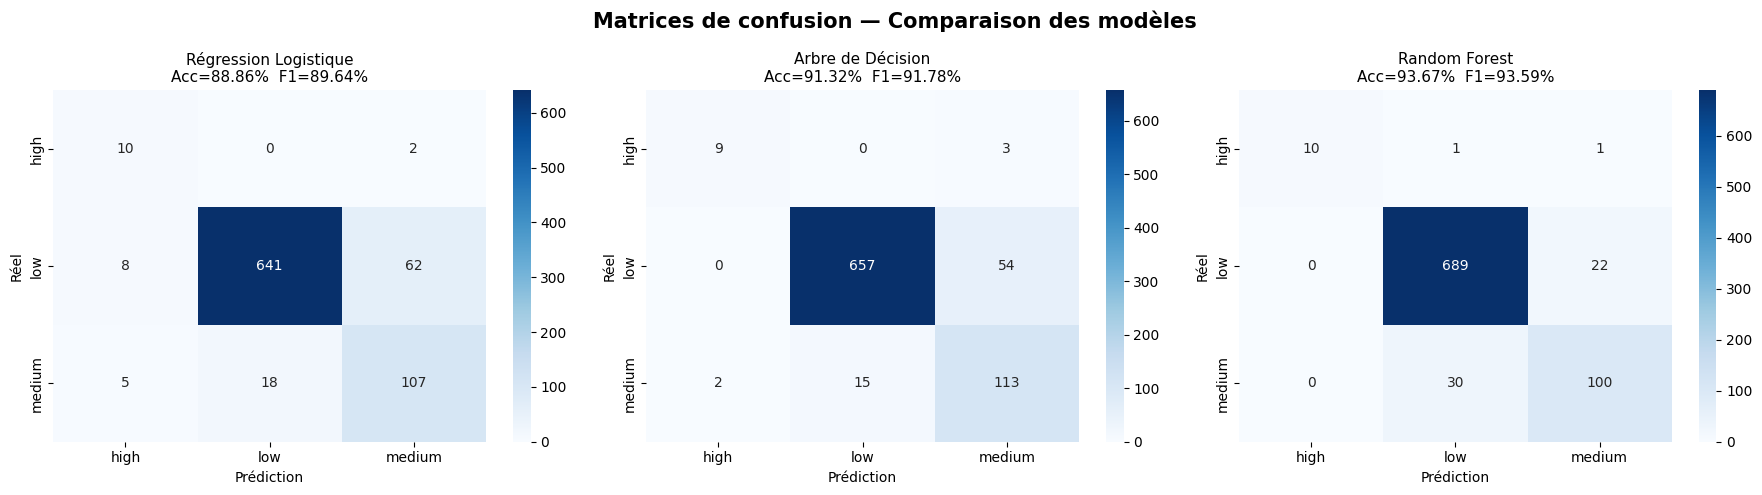

Figure sauvegardée : confusion_matrices.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Matrices de confusion — Comparaison des modèles', fontsize=15, fontweight='bold')

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=le.classes_, yticklabels=le.classes_, ax=ax
    )
    ax.set_title(f'{name}\nAcc={res["Accuracy"]:.2%}  F1={res["F1-score"]:.2%}',
                 fontsize=11)
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Réel')

plt.tight_layout()
plt.show()
print('Figure sauvegardée : confusion_matrices.png')

## 7. Comparaison des modèles

               Modèle  Accuracy  F1-score
        Random Forest  0.936694  0.935923
    Arbre de Décision  0.913247  0.917763
Régression Logistique  0.888628  0.896380


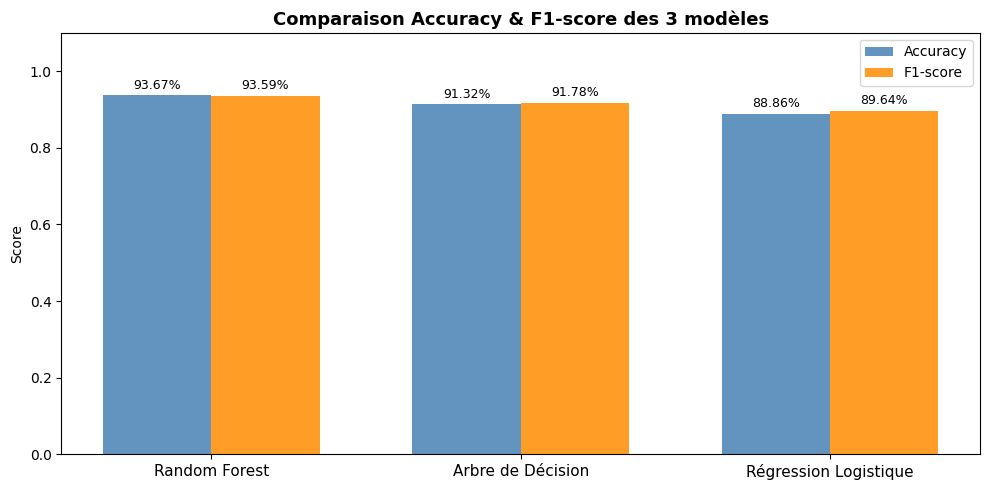


🏆 Meilleur modèle : Random Forest
   Accuracy : 0.9367
   F1-score : 0.9359


In [21]:
# ----- Tableau récapitulatif -----
comparison_df = pd.DataFrame({
    'Modèle'   : list(results.keys()),
    'Accuracy' : [v['Accuracy']  for v in results.values()],
    'F1-score' : [v['F1-score']  for v in results.values()]
})
comparison_df = comparison_df.sort_values('F1-score', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

# ----- Graphique de comparaison -----
x = np.arange(len(comparison_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy',
               color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, comparison_df['F1-score'], width, label='F1-score',
               color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Modèle'], fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison Accuracy & F1-score des 3 modèles', fontsize=13, fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Identifier le meilleur modèle
best_model_name = comparison_df.iloc[0]['Modèle']
print(f'\n🏆 Meilleur modèle : {best_model_name}')
print(f'   Accuracy : {comparison_df.iloc[0]["Accuracy"]:.4f}')
print(f'   F1-score : {comparison_df.iloc[0]["F1-score"]:.4f}')

## 8. Export du modèle choisi (.pkl) (Après la décision final)

In [22]:
# Exporter le meilleur modèle + scaler + label encoder
os.makedirs('../models', exist_ok=True)

best_model = trained_models[best_model_name]

with open('../models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Sauvegarder aussi les features utilisées
with open('../models/features.pkl', 'wb') as f:
    pickle.dump(features, f)

print(f'✅ Modèle exporté : ../models/best_model.pkl  ({best_model_name})')
print('✅ Scaler exporté : ../models/scaler.pkl')
print('✅ LabelEncoder   : ../models/label_encoder.pkl')
print('✅ Features        : ../models/features.pkl')

# --- Vérification rapide : rechargement et prédiction test ---
with open('../models/best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

sample = X_test[:3]
preds  = loaded_model.predict(sample)
print('\nTest de rechargement — prédictions sur 3 échantillons :')
for i, p in enumerate(preds):
    print(f'  Echantillon {i+1} → {le.inverse_transform([p])[0]}')

✅ Modèle exporté : ../models/best_model.pkl  (Random Forest)
✅ Scaler exporté : ../models/scaler.pkl
✅ LabelEncoder   : ../models/label_encoder.pkl
✅ Features        : ../models/features.pkl

Test de rechargement — prédictions sur 3 échantillons :
  Echantillon 1 → low
  Echantillon 2 → low
  Echantillon 3 → low


## 9. Résumé — À envoyer à la coordinatrice

In [23]:
print('=' * 60)
print('  RÉSUMÉ DES RÉSULTATS — PFE 2026')
print('  Suivi des Catastrophes Naturelles au Maroc')
print('=' * 60)
print()
print(f'  Dataset       : data_seismes.csv')
print(f'  Nb d\'exemples : {df_clean.shape[0]}')
print(f'  Features      : {len(features)}')
print(f'  Classes       : {list(le.classes_)}')
print(f'  Rééquilibrage : SMOTE')
print()
print('  Performances des modèles :')
print('-' * 45)
print(f'  {"Modèle":<28} {"Accuracy":>9} {"F1-score":>9}')
print('-' * 45)
for _, row in comparison_df.iterrows():
    marker = '🏆' if row['Modèle'] == best_model_name else '  '
    print(f'{marker} {row["Modèle"]:<26} {row["Accuracy"]:>8.2%} {row["F1-score"]:>8.2%}')
print('-' * 45)
print()
print(f'  ✅ Modèle retenu : {best_model_name}')
print(f'     Fichier       : ../models/best_model.pkl')
print('=' * 60)

  RÉSUMÉ DES RÉSULTATS — PFE 2026
  Suivi des Catastrophes Naturelles au Maroc

  Dataset       : data_seismes.csv
  Nb d'exemples : 2841
  Features      : 11
  Classes       : ['high', 'low', 'medium']
  Rééquilibrage : SMOTE

  Performances des modèles :
---------------------------------------------
  Modèle                        Accuracy  F1-score
---------------------------------------------
🏆 Random Forest                93.67%   93.59%
   Arbre de Décision            91.32%   91.78%
   Régression Logistique        88.86%   89.64%
---------------------------------------------

  ✅ Modèle retenu : Random Forest
     Fichier       : ../models/best_model.pkl
